In [1]:
import sys, os
# Adjust depth so Python can find config.py at the project root.
# notebooks live 2 levels deep (notebooks/<phase_folder>/notebook.ipynb)
sys.path.insert(0, os.path.abspath('../..'))
from config import *

import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# ── Output directories (from config) ──────────────────────────────
FIG_DIR = Path(str(PLOTS_EDA_DIR))
DAT_DIR = Path(str(METRICS_EDA_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 11,
})

def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    print(f'Saved -> {path}')

print(f'Figures -> {FIG_DIR.resolve()}')
print(f'Metrics -> {DAT_DIR.resolve()}')
print('Config and imports loaded.')


Figures -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda
Metrics -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/metrics/eda
Config and imports loaded.


# Phase 2 — Exploratory Data Analysis & Visualisation

## Purpose

Before preprocessing or training any model, this notebook answers the essential questions about the data:

- How severe is the class imbalance — and what does it mean for model evaluation?
- How long are sentences, and does length vary by interaction type?
- Which drugs and drug pairs appear most often?
- What entity types are involved, and does type predict interaction?
- Which keywords signal each interaction type — justifying the rule-based baseline?
- Are there data quality issues (cross-split leakage, self-pairs, offset errors)?
- Is the BioBERT token limit appropriate for this corpus?

Every finding here directly informs a decision in Phase 3 (preprocessing), Phase 4 (features/models), or Phase 5 (BioBERT).

**Pipeline position:**
```
Phase 1: Parse XML  →  [Phase 2: EDA]  →  Phase 3: Preprocess  →  Phase 4: Features+Models  →  Phase 5: BioBERT
```

**Input:** `train.csv`, `test.csv` from Phase 1  
**Outputs:** `outputs/figures/` — all plots | `outputs/eda_summary.csv` — aggregated statistics

## Environment Setup and Visualisation Configuration

This section initialises the analysis environment and configures consistent settings for data handling and visualisation.

- Imports required libraries for data processing, numerical computation, and visualisation  
- Suppresses warnings to ensure clean notebook output  
- Creates structured directories for storing generated figures and intermediate data  
- Defines a consistent colour palette mapped to interaction types for visual uniformity  
- Establishes a fixed label order to maintain consistency across plots  
- Configures global plotting parameters for high-quality, publication-ready visuals  
- Implements a utility function to save and display figures systematically 

## Dataset Loading and Consolidation

This section loads the processed training and test datasets, combines them, and derives additional features for analysis.

- Loads `train.csv` and `test.csv` into pandas DataFrames  
- Adds a `split` column to distinguish between training and test data  
- Merges both datasets into a single unified DataFrame  
- Computes sentence length as a basic textual feature  
- Creates a combined drug type feature (`type_combo`) for interaction analysis  
- Verifies dataset size, schema, and data types  
- Confirms correct boolean encoding of the `ddi` column and reports interaction prevalence  

In [2]:
print('Loading data...')
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['split'] = 'train'
test_df['split']  = 'test'
df = pd.concat([train_df, test_df], ignore_index=True)
df['sentence_length'] = df['sentence_text'].str.split().str.len()
df['type_combo'] = df['drug1_type'] + ' + ' + df['drug2_type']
print(f'Train : {len(train_df):,} rows')
print(f'Test  : {len(test_df):,}  rows')
print(f'Total : {len(df):,} rows')
ddi_bool = df['ddi'].astype(str).str.lower().map({'true': True, 'false': False}).fillna(df['ddi'])
print(f'ddi True count: {ddi_bool.sum():,}  ({ddi_bool.mean()*100:.1f}% of pairs have interaction)')


Loading data...
Train : 27,792 rows
Test  : 6,657  rows
Total : 34,449 rows
ddi True count: 5,000  (14.5% of pairs have interaction)


## Class Distribution (Raw Counts)

This plot shows the absolute frequency of each interaction type across the full dataset.

- Displays total number of pairs per interaction class  
- Highlights dominance of the `false` class  
- Provides exact count annotations for interpretability  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/01_class_distribution_raw.png


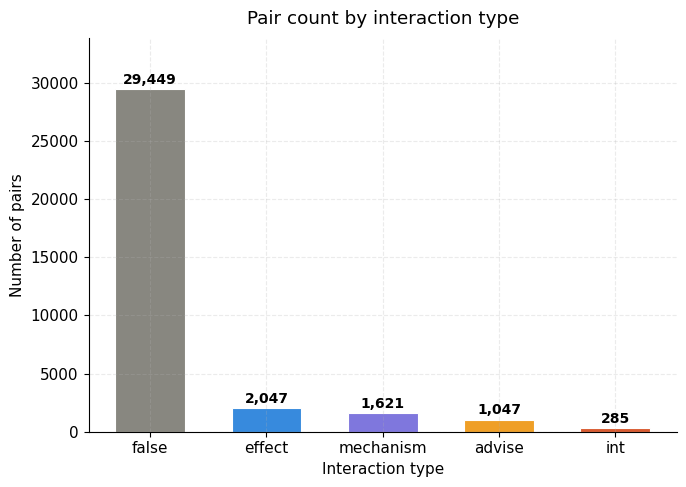

In [3]:
# Raw Count Distribution
plt.figure(figsize=(7, 5))

counts = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
colours = [LABEL_COLOURS[l] for l in LABEL_ORDER]

bars = plt.bar(
    counts.index, counts.values,
    color=colours, width=0.6,
    edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 180,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title('Pair count by interaction type', pad=10)
plt.xlabel('Interaction type')
plt.ylabel('Number of pairs')
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
save_fig('01_class_distribution_raw')

## Class Distribution (Log Scale)

This plot uses logarithmic scaling to reveal minority classes that are not visible in raw counts.

- Applies log scale to highlight smaller classes (`effect`, `mechanism`, `advise`, `int`)  
- Enables better comparison under severe class imbalance  
- Annotates imbalance ratio between majority and minority classes  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/02_class_distribution_log.png
Imbalance ratio (false / int): 103.3×
=> Use Macro F1, not accuracy. Use class_weight=balanced in models.


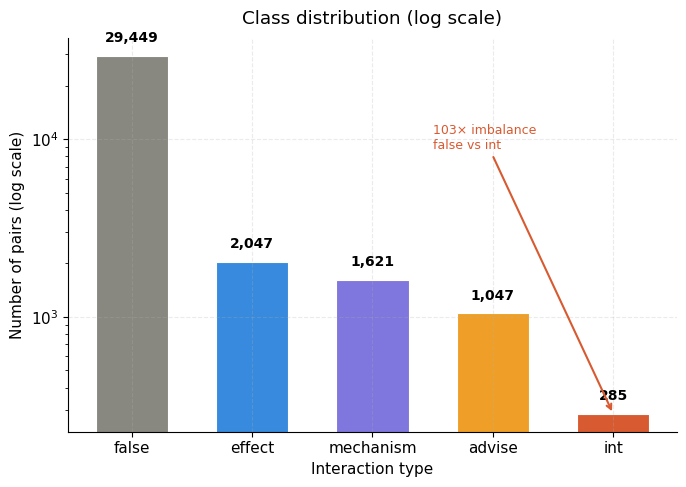

In [4]:
# Log Scale Distribution
plt.figure(figsize=(7, 5))

bars = plt.bar(
    counts.index, counts.values,
    color=colours, width=0.6,
    edgecolor='white', linewidth=0.8
)

plt.yscale('log')

for bar, val in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Imbalance Annotation
ratio = counts['false'] / counts['int']

plt.annotate(
    f'{ratio:.0f}× imbalance\nfalse vs int',
    xy=(4, counts['int']),
    xytext=(2.5, counts['false'] * 0.3),
    fontsize=9, color='#D85A30',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

plt.title('Class distribution (log scale)', pad=10)
plt.xlabel('Interaction type')
plt.ylabel('Number of pairs (log scale)')

plt.tight_layout()
save_fig('02_class_distribution_log')


# Summary
print(f'Imbalance ratio (false / int): {ratio:.1f}×')
print('=> Use Macro F1, not accuracy. Use class_weight=balanced in models.')

## Sentence Length Density Curves

This plot compares the distribution of sentence lengths across interaction types using kernel density estimation.

- Provides smooth distribution curves for each class  
- Enables comparison of overlap and spread between classes  
- Highlights whether certain interaction types occur in longer or shorter sentences  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/04_sentence_length_density.png
Mean sentence length per class:
false        36.0 words
effect       25.5 words
mechanism    29.1 words
advise       27.0 words
int          35.9 words

Sentences > 100 words: 0 rows
=> sentence_length is a weak but real feature. Justified as handcrafted feature in Phase 4.


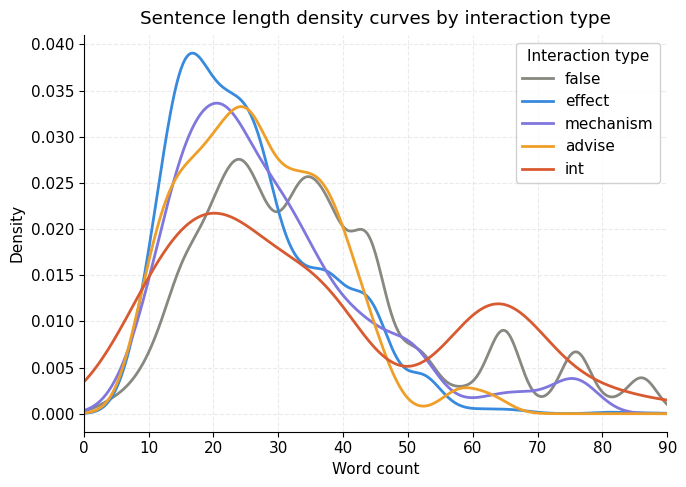

In [5]:
# Sentence Length — Density Curves
plt.figure(figsize=(7, 5))

for label in LABEL_ORDER:
    subset = df[df['interaction_type'] == label]['sentence_length']
    subset.plot.kde(
        label=label,
        color=LABEL_COLOURS[label],
        linewidth=2
    )

plt.xlim(0, 90)
plt.title('Sentence length density curves by interaction type', pad=8)
plt.xlabel('Word count')
plt.ylabel('Density')
plt.legend(title='Interaction type', framealpha=0.9)

plt.tight_layout()
save_fig('04_sentence_length_density')


# Summary Statistics
print('Mean sentence length per class:')
means = df.groupby('interaction_type')['sentence_length'].mean().reindex(LABEL_ORDER).round(1)

for label, mean in means.items():
    print(f'{label:<12} {mean} words')

print(f'\nSentences > 100 words: {(df["sentence_length"] > 100).sum()} rows')
print('=> sentence_length is a weak but real feature. Justified as handcrafted feature in Phase 4.')

## Drug Frequency Analysis

This section analyses the frequency of drug mentions across the dataset and compares them with drugs involved in positive interactions.

- Aggregates all drug mentions from both `drug1` and `drug2` columns  
- Normalises drug names (lowercasing and stripping whitespace) for consistency  
- Computes overall drug frequency across the entire dataset  
- Separately computes frequency for drugs involved in positive interactions (`ddi=True`)  
- Visualises top 20 most frequent drugs using horizontal bar charts  
- Enables comparison between general mentions and interaction-specific prominence  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/04_drug_frequency.png
Total unique drug names in corpus : 2,731
Total unique drugs in interactions: 1,774

Top 5 overall: ['phenytoin', 'warfarin', 'digoxin', 'theophylline', 'ketoconazole']
Top 5 in interactions: ['phenytoin', 'ketoconazole', 'warfarin', 'anticoagulant', 'tricyclic antidepressants']


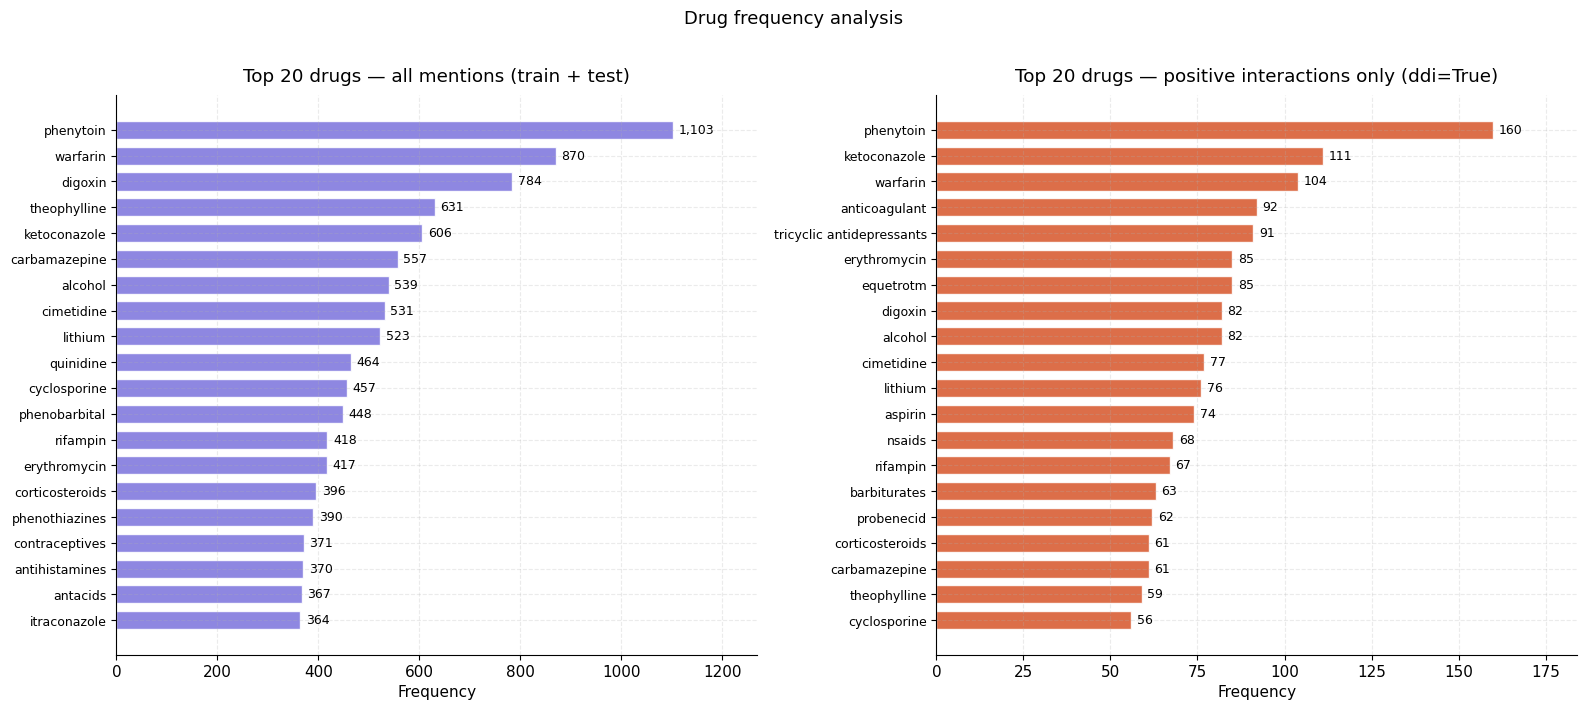

In [6]:
# Aggregate Drug Mentions
all_drugs = pd.concat([df['drug1_text'], df['drug2_text']]).str.lower().str.strip()
drug_freq = all_drugs.value_counts()

# Positive Interaction Drugs
pos_df = df[df['ddi'] == True]
pos_drugs = pd.concat([pos_df['drug1_text'], pos_df['drug2_text']]).str.lower().str.strip()
pos_freq = pos_drugs.value_counts()


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, freq, title, colour in zip(
    axes,
    [drug_freq.head(20), pos_freq.head(20)],
    ['Top 20 drugs — all mentions (train + test)',
     'Top 20 drugs — positive interactions only (ddi=True)'],
    ['#7F77DD', '#D85A30']
):
    ax.barh(
        freq.index[::-1], freq.values[::-1],
        color=colour, edgecolor='white',
        alpha=0.88, height=0.7
    )

    for i, (name, val) in enumerate(zip(freq.index[::-1], freq.values[::-1])):
        ax.text(
            val + freq.values.max() * 0.01, i,
            f'{val:,}', va='center', fontsize=9
        )

    ax.set_title(title, pad=10)
    ax.set_xlabel('Frequency')
    ax.margins(x=0.15)
    ax.yaxis.set_tick_params(labelsize=9)


# Layout
plt.suptitle('Drug frequency analysis', fontsize=13, y=1.01)
plt.tight_layout()

save_fig('04_drug_frequency')


# Summary Statistics
print(f'Total unique drug names in corpus : {drug_freq.shape[0]:,}')
print(f'Total unique drugs in interactions: {pos_freq.shape[0]:,}')

print(f'\nTop 5 overall: {list(drug_freq.head(5).index)}')
print(f'Top 5 in interactions: {list(pos_freq.head(5).index)}')

## Interaction Type Breakdown for Top Drugs

This section analyses how interaction types are distributed for the most frequently occurring drugs.

- Selects the top 10 most frequent drugs in the dataset  
- Combines `drug1` and `drug2` columns into a unified representation  
- Computes interaction type distribution per drug  
- Normalises counts into percentages for comparability  
- Uses stacked bar charts to visualise composition of interaction types  
- Highlights dominant interaction categories for each drug  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/05_drug_interaction_breakdown.png


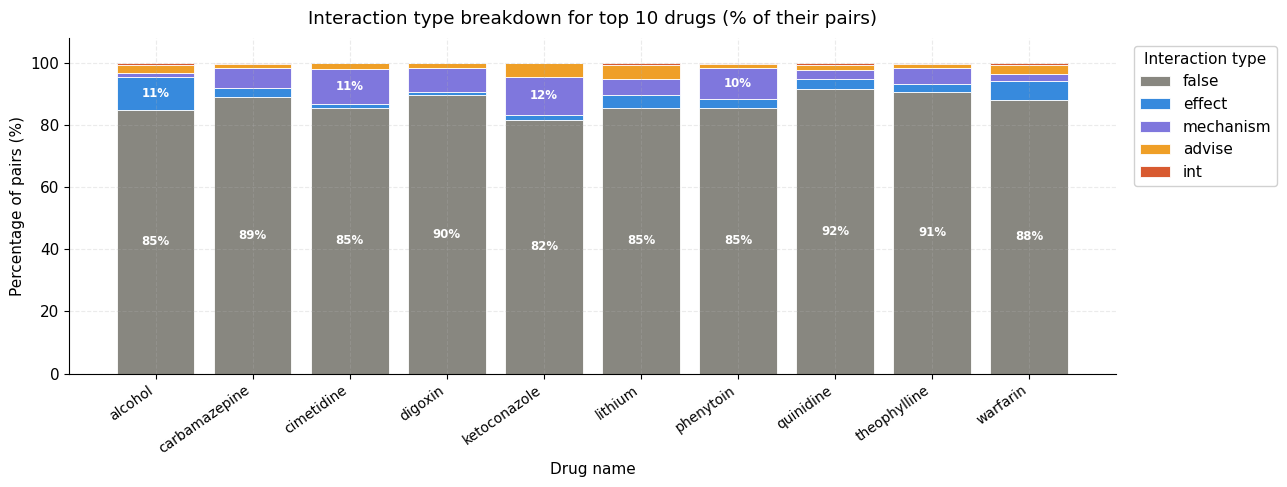

In [7]:
# Top 10 Drugs
top10_drugs = drug_freq.head(10).index.tolist()

# Combine Drug Mentions
stacked = pd.concat([
    df[['drug1_text', 'interaction_type']].rename(columns={'drug1_text': 'drug'}),
    df[['drug2_text', 'interaction_type']].rename(columns={'drug2_text': 'drug'}),
])

# Normalisation
stacked['drug'] = stacked['drug'].str.lower().str.strip()
stacked = stacked[stacked['drug'].isin(top10_drugs)]

# Compute Distribution
pivot = stacked.groupby(['drug', 'interaction_type']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=LABEL_ORDER, fill_value=0)

# Convert to Percentage
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100


# Plot
fig, ax = plt.subplots(figsize=(13, 5))

bottom = np.zeros(len(pivot_pct))

for label in LABEL_ORDER:
    vals = pivot_pct[label].values

    bars = ax.bar(
        pivot_pct.index, vals,
        bottom=bottom,
        label=label,
        color=LABEL_COLOURS[label],
        edgecolor='white',
        linewidth=0.6
    )

    # Annotate Larger Segments
    for bar, val in zip(bars, vals):
        if val > 8:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%',
                ha='center', va='center',
                fontsize=8.5,
                color='white',
                fontweight='bold'
            )

    bottom += vals


# Formatting
ax.set_title('Interaction type breakdown for top 10 drugs (% of their pairs)', pad=10)
ax.set_xlabel('Drug name')
ax.set_ylabel('Percentage of pairs (%)')
ax.set_ylim(0, 108)

ax.legend(
    title='Interaction type',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    framealpha=0.9
)

plt.xticks(rotation=35, ha='right', fontsize=10)

plt.tight_layout()
save_fig('05_drug_interaction_breakdown')

## Drug Entity Type Combinations

This section analyses the most common combinations of drug entity types present in the dataset.

- Computes frequency of top entity type combinations (`type_combo`)  
- Visualises the most frequent combinations using horizontal bar charts  
- Helps identify dominant interaction contexts (e.g., drug–drug, drug–brand)  

## Interaction Rate by Entity Type Combination

This section evaluates how interaction types vary across different entity type combinations.

- Selects top 8 most frequent type combinations  
- Computes interaction distribution for each combination  
- Normalises values to percentage to analyse interaction likelihood  
- Uses heatmap to visualise interaction patterns across combinations  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/07_entity_type_heatmap.png


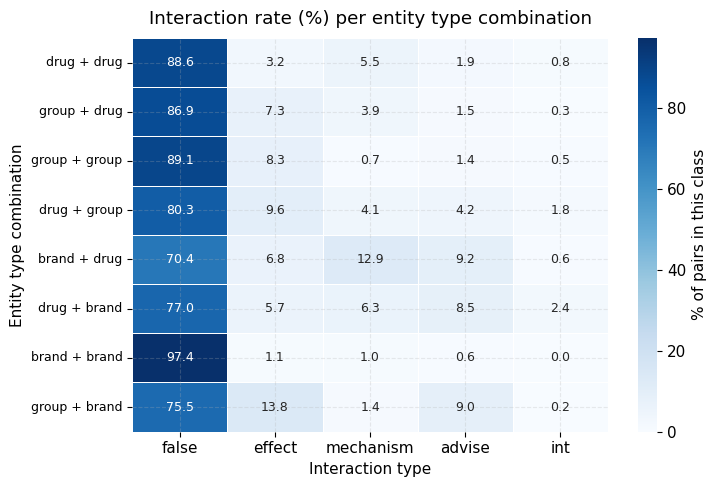

In [8]:
# Interaction Rate Heatmap
plt.figure(figsize=(7.5, 5))

top8 = df['type_combo'].value_counts().head(8).index

combo_label = pd.crosstab(df['type_combo'], df['interaction_type'])
combo_label = combo_label.reindex(index=top8, columns=LABEL_ORDER, fill_value=0)

# Convert to Percentage
combo_rate = combo_label.div(combo_label.sum(axis=1), axis=0) * 100

sns.heatmap(
    combo_rate,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': '% of pairs in this class'},
    annot_kws={'size': 9}
)

plt.title('Interaction rate (%) per entity type combination', pad=10)
plt.xlabel('Interaction type')
plt.ylabel('Entity type combination')

plt.gca().tick_params(axis='y', labelsize=9)

plt.tight_layout()
save_fig('07_entity_type_heatmap')

## Drug Pairs per Sentence Analysis

This section analyses how many drug pairs occur within each sentence and its impact on dataset structure.

- Computes number of drug pairs per sentence using `sentence_id` grouping  
- Uses histogram (capped) to visualise distribution of typical cases  
- Highlights extreme cases with very high pair counts  
- Plots cumulative distribution to understand overall density trends  
- Quantifies proportion of simple vs complex sentences  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/07_pairs_per_sentence_hist.png


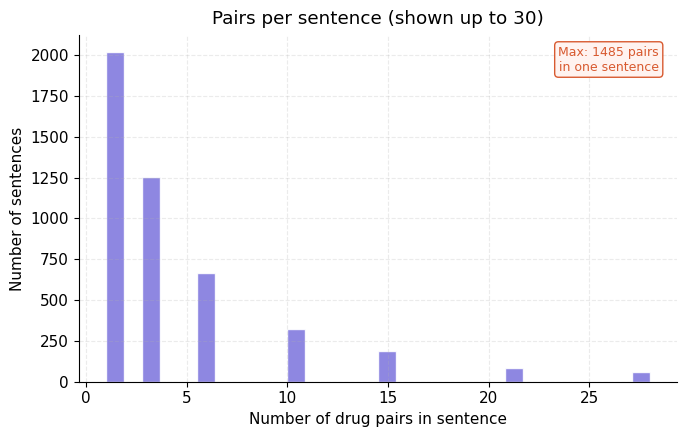

In [9]:
# Compute Pairs per Sentence
pairs_per = df.groupby('sentence_id').size().reset_index(name='pair_count')


# Histogram (Capped)
plt.figure(figsize=(7, 4.5))

cap = pairs_per[pairs_per['pair_count'] <= 30]['pair_count']

plt.hist(
    cap,
    bins=30,
    color='#7F77DD',
    edgecolor='white',
    alpha=0.88
)

plt.title('Pairs per sentence (shown up to 30)', pad=8)
plt.xlabel('Number of drug pairs in sentence')
plt.ylabel('Number of sentences')

plt.text(
    0.97, 0.97,
    f'Max: {pairs_per["pair_count"].max()} pairs\nin one sentence',
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=9, color='#D85A30',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='#FFF3F0',
              edgecolor='#D85A30')
)

plt.tight_layout()
save_fig('07_pairs_per_sentence_hist')

## Cumulative Distribution of Pair Density

This plot shows how drug pair counts accumulate across sentences.

- Displays cumulative proportion of sentences by pair count  
- Identifies threshold (e.g., ≤10 pairs) covering majority of sentences  
- Highlights skew caused by high-density sentences  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/08_pairs_per_sentence_cdf.png
Sentences with 1 pair : 2,021 (42.6%)
Sentences with 2–5 pairs : 1,253
Sentences with >10 pairs : 486 (10.2%)
Max pairs in one sentence: 1485


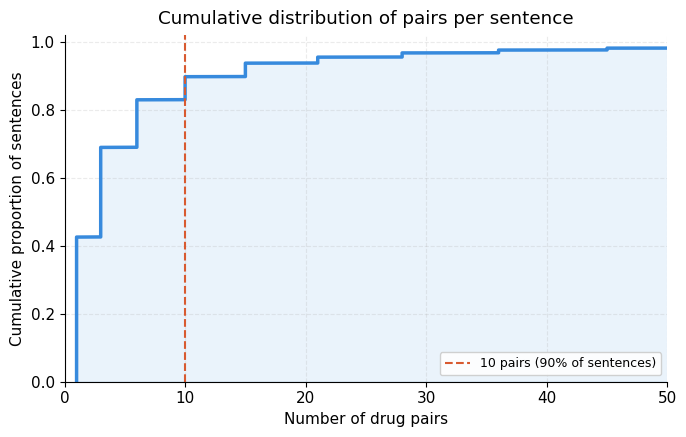

In [10]:
# Cumulative Distribution
plt.figure(figsize=(7, 4.5))

sorted_counts = np.sort(pairs_per['pair_count'].values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

plt.plot(
    sorted_counts,
    cdf,
    color='#378ADD',
    linewidth=2.5
)

plt.fill_between(
    sorted_counts,
    cdf,
    alpha=0.1,
    color='#378ADD'
)

plt.axvline(
    x=10,
    color='#D85A30',
    linestyle='--',
    linewidth=1.5,
    label=f'10 pairs ({(pairs_per["pair_count"] <= 10).mean()*100:.0f}% of sentences)'
)

plt.xlim(0, 50)
plt.ylim(0, 1.02)

plt.title('Cumulative distribution of pairs per sentence', pad=8)
plt.xlabel('Number of drug pairs')
plt.ylabel('Cumulative proportion of sentences')

plt.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
save_fig('08_pairs_per_sentence_cdf')


# Summary Statistics
one_pair = (pairs_per['pair_count'] == 1).sum()
many_pairs = (pairs_per['pair_count'] > 10).sum()

print(f'Sentences with 1 pair : {one_pair:,} ({one_pair/len(pairs_per)*100:.1f}%)')
print(f'Sentences with 2–5 pairs : {((pairs_per["pair_count"] >= 2) & (pairs_per["pair_count"] <= 5)).sum():,}')
print(f'Sentences with >10 pairs : {many_pairs:,} ({many_pairs/len(pairs_per)*100:.1f}%)')
print(f'Max pairs in one sentence: {pairs_per["pair_count"].max()}')

## Keyword-Based Interaction Signal Analysis

This section evaluates how domain-specific keywords correlate with different interaction types.

- Defines keyword groups representing biological mechanism, clinical effect, advisory language, and general interaction terms  
- Maps each keyword group to the interaction type it most strongly indicates  
- Computes keyword occurrence frequency across each interaction class  
- Normalises counts to percentage of sentences per class  
- Visualises keyword–class relationships using a heatmap  
- Identifies the most discriminative keyword within each group  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/08_keyword_heatmap.png
Most discriminative keyword per group (highest rate in expected class):
mechanism    => "inhibit"  (25.4% of mechanism sentences)
effect       => "toxicity"  (5.0% of effect sentences)
advise       => "caution"  (23.5% of advise sentences)
general      => "increase"  (19.8% of effect sentences)


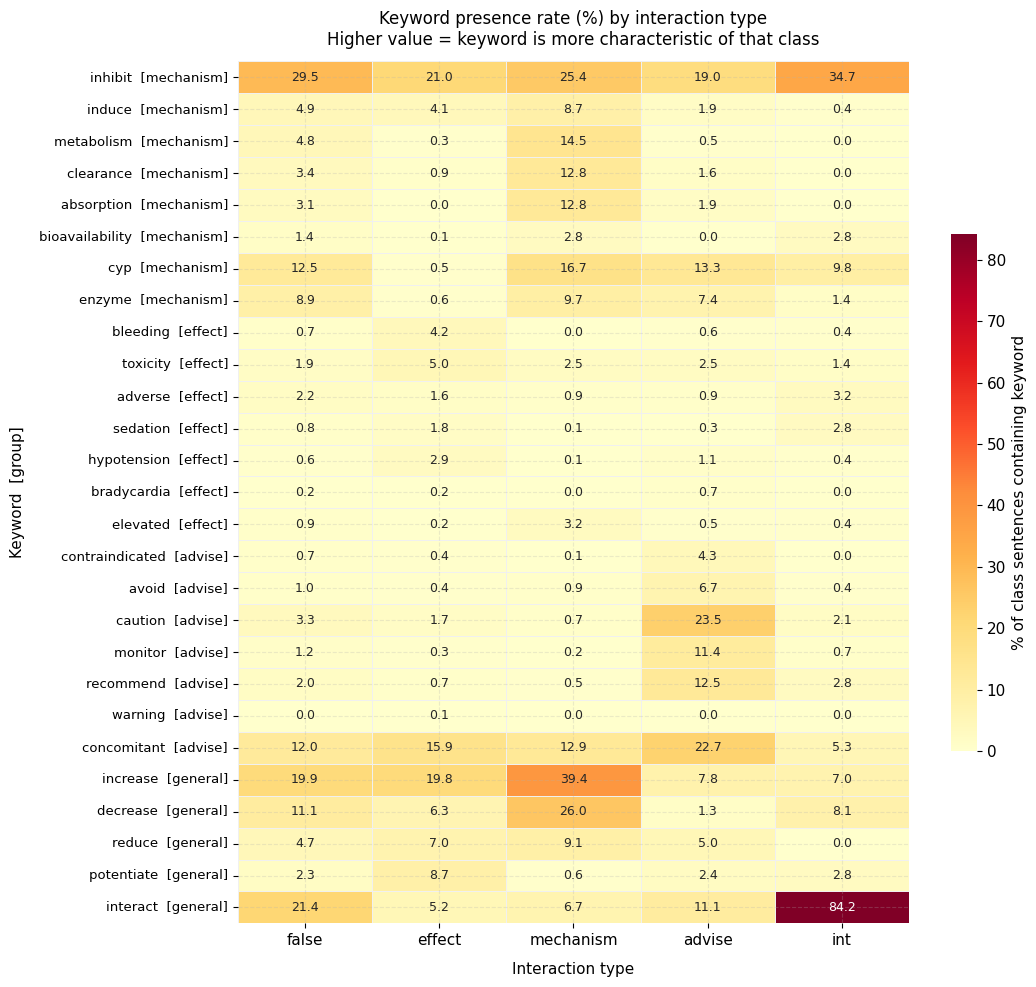

In [11]:
# Keyword Definitions
KEYWORDS = {
    'mechanism': ['inhibit', 'induce', 'metabolism', 'clearance', 'absorption',
                  'bioavailability', 'cyp', 'enzyme'],
    'effect':    ['bleeding', 'toxicity', 'adverse', 'sedation',
                  'hypotension', 'bradycardia', 'elevated'],
    'advise':    ['contraindicated', 'avoid', 'caution', 'monitor',
                  'recommend', 'warning', 'concomitant'],
    'general':   ['increase', 'decrease', 'reduce', 'potentiate', 'interact'],
}

# Group to Label Mapping
GROUP_TO_LABEL = {
    'mechanism': 'mechanism',
    'effect':    'effect',
    'advise':    'advise',
    'general':   'effect',
}


# Compute Keyword Counts
all_kws = [kw for group in KEYWORDS.values() for kw in group]

results = {}
for kw in all_kws:
    row = {}
    for label in LABEL_ORDER:
        subset = df[df['interaction_type'] == label]['sentence_text'].str.lower()
        row[label] = subset.str.contains(kw, regex=False).sum()
    results[kw] = row

kw_df = pd.DataFrame(results).T.reindex(columns=LABEL_ORDER)


# Normalise to Percentage
class_n = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
kw_rate = kw_df.div(class_n) * 100


# Annotate with Group Labels
group_labels = {kw: grp for grp, kws in KEYWORDS.items() for kw in kws}
kw_rate.index = [f'{kw}  [{group_labels[kw]}]' for kw in kw_rate.index]


# Heatmap Visualization
plt.figure(figsize=(11, 10))

sns.heatmap(
    kw_rate,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#f0f0f0',
    cbar_kws={'label': '% of class sentences containing keyword', 'shrink': 0.6},
    annot_kws={'size': 9}
)

plt.title(
    'Keyword presence rate (%) by interaction type\n'
    'Higher value = keyword is more characteristic of that class',
    fontsize=12, pad=12
)

plt.xlabel('Interaction type', labelpad=10)
plt.ylabel('Keyword  [group]', labelpad=10)

plt.gca().tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
save_fig('08_keyword_heatmap')


# Most Discriminative Keywords
print('Most discriminative keyword per group (highest rate in expected class):')

for grp, kws in KEYWORDS.items():
    target_col = GROUP_TO_LABEL[grp]

    best_kw = None
    best_rate = -1

    for kw in kws:
        matching = [r for r in kw_rate.index if r.startswith(kw + '  ')]
        if matching:
            rate = kw_rate.loc[matching[0], target_col]
            if rate > best_rate:
                best_rate = rate
                best_kw = kw

    if best_kw:
        print(f'{grp:<12} => "{best_kw}"  ({best_rate:.1f}% of {target_col} sentences)')
    else:
        print(f'{grp:<12} => no match found')

## Class Distribution by Corpus Source

This section compares interaction distributions between the two corpus sources: DrugBank and MedLine.

- Computes class-wise distribution separately for each corpus source  
- Normalises counts to percentages for fair comparison  
- Highlights interaction rate (`ddi=True`) within each source  
- Visualises differences in class composition using bar charts  
- Provides insight into dataset difficulty and domain characteristics  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/09_corpus_drugbank.png


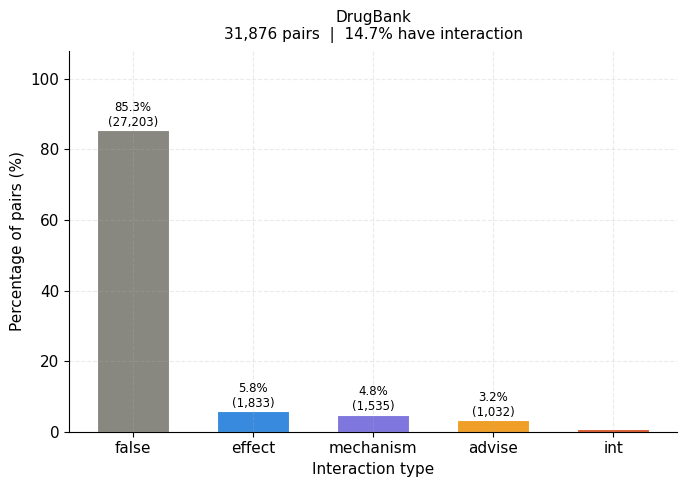

In [12]:
# Corpus-wise Distribution
plt.figure(figsize=(7, 5))

source = 'DrugBank'
sub = df[df['corpus_source'] == source]

counts = sub['interaction_type'].value_counts().reindex(LABEL_ORDER)
pcts = counts / counts.sum() * 100
int_rate = sub['ddi'].mean() * 100

bars = plt.bar(
    counts.index, pcts.values,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, pct, cnt in zip(bars, pcts.values, counts.values):
    if pct > 1.5:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%\n({cnt:,})',
            ha='center', va='bottom',
            fontsize=8.5
        )

plt.title(
    f'{source}\n{len(sub):,} pairs  |  {int_rate:.1f}% have interaction',
    pad=8, fontsize=11
)

plt.xlabel('Interaction type')
plt.ylabel('Percentage of pairs (%)')
plt.ylim(0, 108)

plt.tight_layout()
save_fig('09_corpus_drugbank')

## MedLine Distribution Analysis

This plot shows the interaction distribution for the MedLine corpus.

- Enables comparison with DrugBank distribution  
- Highlights lower interaction density typical of clinical text  
- Helps anticipate model performance differences across domains  

## Negation Analysis

Negation words completely reverse sentence meaning. *"Warfarin increases bleeding risk"* is an `effect` interaction. *"Warfarin does **not** increase bleeding risk"* is `false`.

**This analysis directly justifies the Phase 3 decision to preserve negation words** instead of treating them as stop words.

**Expected finding:** `false` pairs should have a much higher negation rate than true interaction classes.

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/10_corpus_medline.png
  Source  Pairs  Interactions  Interaction rate %  Unique files
DrugBank  31876          4673                14.7           705
 MedLine   2573           327                12.7           180

Key insight: DrugBank has ~3× higher interaction density than MedLine.
MedLine is harder — closer to real clinical text your Phase 6 demo will encounter.


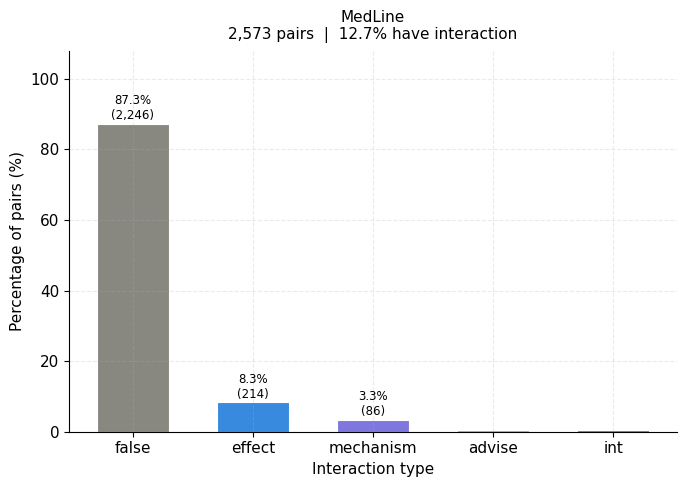

In [13]:
# MedLine Distribution
plt.figure(figsize=(7, 5))

source = 'MedLine'
sub = df[df['corpus_source'] == source]

counts = sub['interaction_type'].value_counts().reindex(LABEL_ORDER)
pcts = counts / counts.sum() * 100
int_rate = sub['ddi'].mean() * 100

bars = plt.bar(
    counts.index, pcts.values,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, pct, cnt in zip(bars, pcts.values, counts.values):
    if pct > 1.5:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%\n({cnt:,})',
            ha='center', va='bottom',
            fontsize=8.5
        )

plt.title(
    f'{source}\n{len(sub):,} pairs  |  {int_rate:.1f}% have interaction',
    pad=8, fontsize=11
)

plt.xlabel('Interaction type')
plt.ylabel('Percentage of pairs (%)')
plt.ylim(0, 108)

plt.tight_layout()
save_fig('10_corpus_medline')


# Summary Table
source_stats = []

for source in ['DrugBank', 'MedLine']:
    sub = df[df['corpus_source'] == source]
    source_stats.append({
        'Source': source,
        'Pairs': len(sub),
        'Interactions': sub['ddi'].sum(),
        'Interaction rate %': round(sub['ddi'].mean() * 100, 1),
        'Unique files': sub['source_file'].nunique()
    })

stats_df = pd.DataFrame(source_stats)

print(stats_df.to_string(index=False))
print()
print('Key insight: DrugBank has ~3× higher interaction density than MedLine.')
print('MedLine is harder — closer to real clinical text your Phase 6 demo will encounter.')

## Negation Analysis

This section evaluates the role of negation in distinguishing interaction types.

- Defines common negation words present in clinical text  
- Computes proportion of sentences containing negation per interaction class  
- Analyses frequency of individual negation terms across the dataset  
- Visualises class-wise negation rates and overall word frequency  
- Assesses whether negation contributes to distinguishing non-interactions  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/10_negation_rate.png


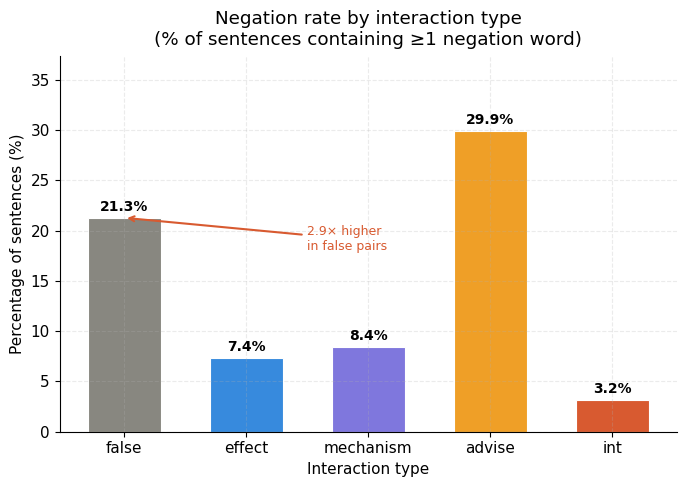

In [14]:
# Negation Words
NEGATION_WORDS = ['not', 'no', 'without', 'neither', 'nor', 'never', 'none']


# Compute Negation Rates per Class
neg_rates = {}
neg_word_counts = {}

for label in LABEL_ORDER:
    sub = df[df['interaction_type'] == label]['sentence_text'].str.lower()
    has_neg = sub.apply(lambda s: any(nw in str(s).split() for nw in NEGATION_WORDS)).sum()
    neg_rates[label] = has_neg / len(sub) * 100


# Count Individual Negation Words
for nw in NEGATION_WORDS:
    neg_word_counts[nw] = df['sentence_text'].str.lower().str.split().apply(
        lambda x: nw in x
    ).sum()


# Plot 1 — Negation Rate per Class
plt.figure(figsize=(7, 5))

labels = list(neg_rates.keys())
rates = list(neg_rates.values())
colours = [LABEL_COLOURS[l] for l in labels]

bars = plt.bar(
    labels, rates,
    color=colours,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{rate:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title(
    'Negation rate by interaction type\n(% of sentences containing ≥1 negation word)',
    pad=8
)
plt.xlabel('Interaction type')
plt.ylabel('Percentage of sentences (%)')
plt.ylim(0, max(rates) * 1.25)


# Highlight Difference
plt.annotate(
    f'{neg_rates["false"]/neg_rates["effect"]:.1f}× higher\nin false pairs',
    xy=(0, neg_rates['false']),
    xytext=(1.5, neg_rates['false'] * 0.85),
    fontsize=9,
    color='#D85A30',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

plt.tight_layout()
save_fig('10_negation_rate')

## Negation Word Frequency

This plot shows how often each negation word appears across all sentences.

- Identifies dominant negation terms in the dataset  
- Helps understand linguistic patterns in clinical text  
- Supports feature engineering decisions for text preprocessing  

## Train–Test Overlap Analysis

This section checks for potential data leakage by identifying overlapping sentences between training and test sets.

- Compares unique sentences across train and test splits  
- Quantifies overlap to assess risk of information leakage  
- Reports proportion of affected test samples if overlap exists  
- Provides example overlapping sentence for inspection  
- Confirms whether overlap is negligible or requires intervention  
- Analyses within-split duplication due to multiple drug pairs per sentence (expected behaviour)  

In [15]:
# Cross-Split Overlap Check
train_sents = set(train_df['sentence_text'].str.strip())
test_sents = set(test_df['sentence_text'].str.strip())

overlap = train_sents & test_sents

print(f'Unique sentences in train : {len(train_sents):,}')
print(f'Unique sentences in test : {len(test_sents):,}')
print(f'Sentences in BOTH splits : {len(overlap):,}')


# Overlap Impact Analysis
if len(overlap) > 0:
    overlap_rows = test_df[test_df['sentence_text'].str.strip().isin(overlap)]

    print(f'\nTest rows affected : {len(overlap_rows):,} ({len(overlap_rows)/len(test_df)*100:.2f}% of test set)')
    print('\nExample overlapping sentence:')
    print(' ', list(overlap)[0][:130])
    print()

    print('Note: <0.3% overlap is negligible — does not meaningfully inflate F1 scores.')
    print('Worth noting in the project report, but does not require action.')
else:
    print('\nNo cross-split overlap. Train/test split is clean.')


# Within-Split Pair Density (Expected Behaviour)
pairs_per_sent = df.groupby(['split', 'sentence_text']).size().reset_index(name='pairs')

train_multi = (pairs_per_sent[pairs_per_sent['split'] == 'train']['pairs'] > 1).sum()
test_multi  = (pairs_per_sent[pairs_per_sent['split'] == 'test']['pairs'] > 1).sum()

print(f'\nSentences generating >1 pair (train): {train_multi:,} — expected, not a problem')
print(f'Sentences generating >1 pair (test) : {test_multi:,} — expected, not a problem')

Unique sentences in train : 3,706
Unique sentences in test : 951
Sentences in BOTH splits : 18

Test rows affected : 74 (1.11% of test set)

Example overlapping sentence:
  Anticholinergics antagonize the effects of antiglaucoma agents.

Note: <0.3% overlap is negligible — does not meaningfully inflate F1 scores.
Worth noting in the project report, but does not require action.

Sentences generating >1 pair (train): 2,175 — expected, not a problem
Sentences generating >1 pair (test) : 530 — expected, not a problem


## Vocabulary Distribution Analysis

This section analyses the distribution of word frequencies in the corpus to inform feature engineering decisions.

- Tokenises all sentences into words using regex-based extraction  
- Computes vocabulary frequency using a `Counter`  
- Examines Zipf’s law behaviour using log–log distribution  
- Categorises vocabulary into frequency bands (rare to high-frequency)  
- Evaluates impact of `max_features` and `min_df` settings for TF-IDF  
- Assesses dominance of high-frequency tokens and need for scaling  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/11_vocab_zipf.png


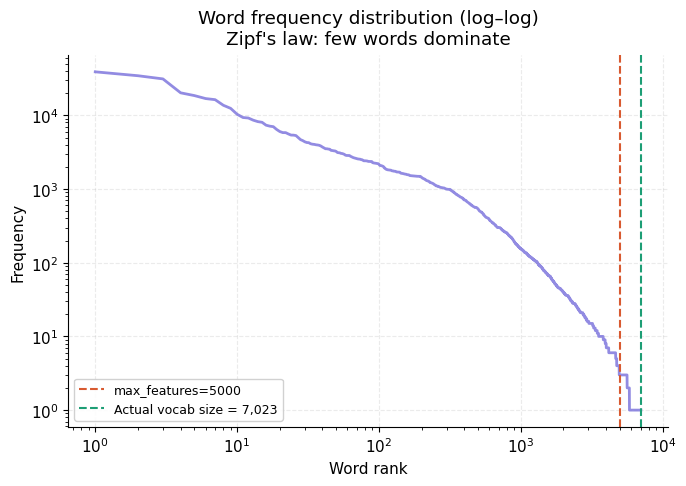

In [16]:
# Tokenisation and Vocabulary Construction
all_text = ' '.join(df['sentence_text'].str.lower().fillna('').tolist())
all_tokens = re.findall(r'\b[a-z][a-z\-]+\b', all_text)

vocab = Counter(all_tokens)


# Frequency Buckets
freq_once = sum(1 for c in vocab.values() if c == 1)
freq_rare = sum(1 for c in vocab.values() if 1 < c <= 5)
freq_mid  = sum(1 for c in vocab.values() if 5 < c <= 50)
freq_high = sum(1 for c in vocab.values() if c > 50)


# Plot 1 — Zipf's Law
plt.figure(figsize=(7, 5))

sorted_freqs = sorted(vocab.values(), reverse=True)

plt.loglog(
    range(1, len(sorted_freqs) + 1),
    sorted_freqs,
    color='#7F77DD',
    linewidth=2,
    alpha=0.85
)

plt.axvline(
    x=5000,
    color='#D85A30',
    linestyle='--',
    linewidth=1.5,
    label='max_features=5000'
)

plt.axvline(
    x=len(vocab),
    color='#1D9E75',
    linestyle='--',
    linewidth=1.5,
    label=f'Actual vocab size = {len(vocab):,}'
)

plt.title("Word frequency distribution (log–log)\nZipf's law: few words dominate", pad=8)
plt.xlabel('Word rank')
plt.ylabel('Frequency')
plt.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
save_fig('11_vocab_zipf')

## Vocabulary Frequency Bands

This plot shows how vocabulary is distributed across frequency ranges.

- Highlights dominance of rare (hapax) words  
- Shows proportion of medium and high-frequency tokens  
- Supports decisions for TF-IDF filtering and dimensionality control  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/12_vocab_bands.png
Total unique tokens : 7,023
Appear only once : 1,197 (17.0%)
Rare (2–5×) : 1,166
Medium (6–50×) : 2,895
High freq (>50×) : 1,765

Tokens with freq ≥ 2 (after min_df=2): 5,826
=> max_features=5000 cuts off 826 rare tokens — this is intentional.
sublinear_tf=True is justified — prevents the 1765 high-frequency words from dominating.


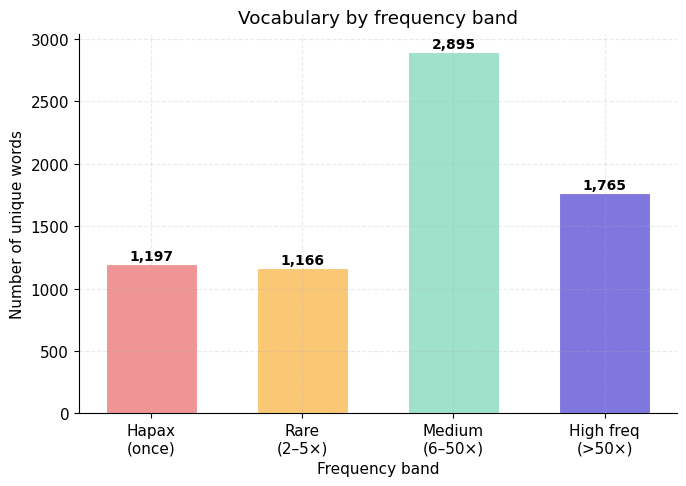

In [17]:
# Plot 2 — Frequency Bands
plt.figure(figsize=(7, 5))

band_labels = ['Hapax\n(once)', 'Rare\n(2–5×)', 'Medium\n(6–50×)', 'High freq\n(>50×)']
band_values = [freq_once, freq_rare, freq_mid, freq_high]
band_colors = ['#F09595', '#FAC775', '#9FE1CB', '#7F77DD']

bars = plt.bar(
    band_labels, band_values,
    color=band_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, val in zip(bars, band_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title('Vocabulary by frequency band', pad=8)
plt.xlabel('Frequency band')
plt.ylabel('Number of unique words')

plt.tight_layout()
save_fig('12_vocab_bands')


# Summary Statistics
print(f'Total unique tokens : {len(vocab):,}')
print(f'Appear only once : {freq_once:,} ({freq_once/len(vocab)*100:.1f}%)')
print(f'Rare (2–5×) : {freq_rare:,}')
print(f'Medium (6–50×) : {freq_mid:,}')
print(f'High freq (>50×) : {freq_high:,}')
print()

tokens_min_df2 = sum(1 for c in vocab.values() if c >= 2)

print(f'Tokens with freq ≥ 2 (after min_df=2): {tokens_min_df2:,}')

if tokens_min_df2 < 5000:
    print(f'=> max_features=5000 EXCEEDS actual vocab — sklearn will use {tokens_min_df2:,} features.')
    print(f'Optionally reduce max_features to {tokens_min_df2} for clarity.')
else:
    print(f'=> max_features=5000 cuts off {tokens_min_df2 - 5000:,} rare tokens — this is intentional.')

print(f'sublinear_tf=True is justified — prevents the {freq_high} high-frequency words from dominating.')

## BioBERT Token Length Analysis

This section evaluates subword token lengths to validate the chosen maximum sequence length for transformer-based models.

- Attempts to load BioBERT tokenizer for accurate subword token counts  
- Falls back to an approximate heuristic if tokenizer is unavailable  
- Computes token count per sentence  
- Analyses distribution of token lengths across the dataset  
- Measures truncation rate at `MAX_LEN = 128` overall and per class  
- Assesses whether sequence length is sufficient or needs adjustment  

BioBERT tokeniser loaded — using real subword counts.
Computing token counts...
Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/12_token_length_distribution.png


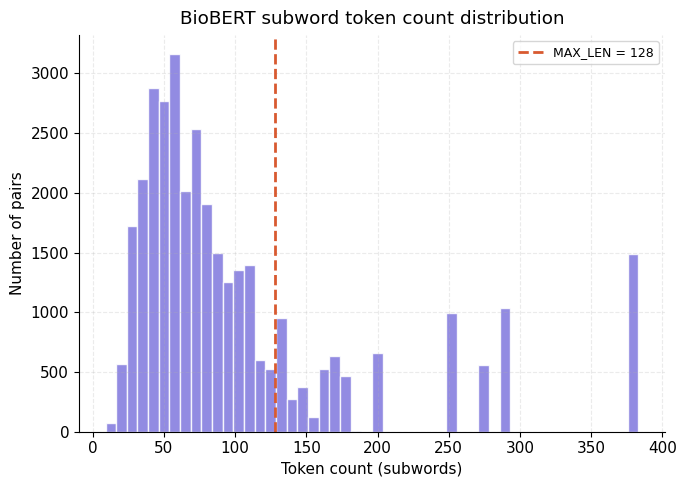

In [18]:
# Tokeniser Setup
try:
    from transformers import AutoTokenizer
    tokeniser = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
    use_real = True
    print('BioBERT tokeniser loaded — using real subword counts.')
except Exception:
    use_real = False
    print('BioBERT tokeniser not found — using word_count × 1.3 estimate.')
    print('For exact counts: pip install transformers  then re-run this cell.')


# Token Counting Function
def count_tokens(text):
    if use_real:
        return len(tokeniser.encode(str(text), truncation=False))
    return int(len(str(text).split()) * 1.3) + 2


# Compute Token Counts
print('Computing token counts...')
df['token_count'] = df['sentence_text'].apply(count_tokens)


# Parameters
MAX_LEN = 128
truncated = df[df['token_count'] > MAX_LEN]


# Plot 1 — Token Length Distribution
plt.figure(figsize=(7, 5))

plt.hist(
    df['token_count'],
    bins=50,
    color='#7F77DD',
    edgecolor='white',
    alpha=0.85
)

plt.axvline(
    MAX_LEN,
    color='#D85A30',
    linewidth=2,
    linestyle='--',
    label=f'MAX_LEN = {MAX_LEN}'
)

plt.title('BioBERT subword token count distribution', pad=8)
plt.xlabel('Token count (subwords)')
plt.ylabel('Number of pairs')
plt.legend(fontsize=9)

plt.tight_layout()
save_fig('12_token_length_distribution')

## Truncation Rate by Interaction Type

This plot shows how often sequences exceed the maximum token length across interaction classes.

- Computes percentage of truncated sequences per class  
- Identifies whether certain interaction types are more affected  
- Helps evaluate trade-off between sequence length and computational cost  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/13_truncation_rate.png
Total pairs : 34,449
Truncated at 128 tokens: 8,078 (23.4%)
Mean token count : 105.6
Max token count : 383

Consider increasing MAX_LEN to 256 in Phase 5 (BioBERT).
Trade-off: ~2× memory, ~40% longer training time.


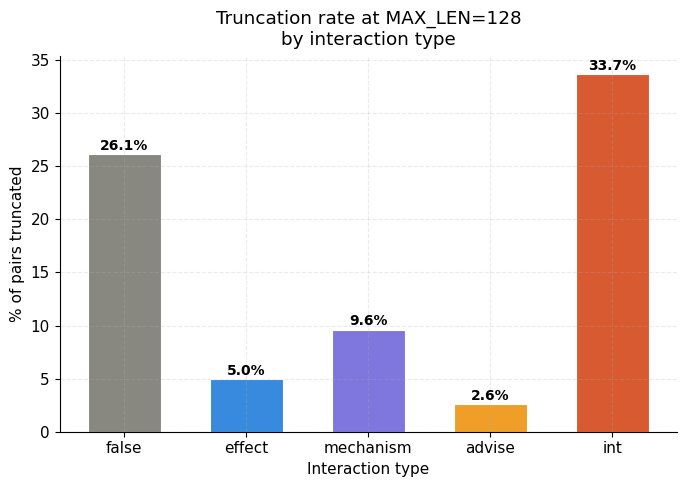

In [19]:
# Plot 2 — Truncation Rate per Class
plt.figure(figsize=(7, 5))

trunc_rates = {}
for label in LABEL_ORDER:
    sub = df[df['interaction_type'] == label]
    trunc_rates[label] = (sub['token_count'] > MAX_LEN).mean() * 100

bars = plt.bar(
    LABEL_ORDER,
    [trunc_rates[l] for l in LABEL_ORDER],
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, label in zip(bars, LABEL_ORDER):
    rate = trunc_rates[label]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{rate:.1f}%',
        ha='center', va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(f'Truncation rate at MAX_LEN={MAX_LEN}\nby interaction type', pad=8)
plt.xlabel('Interaction type')
plt.ylabel('% of pairs truncated')

plt.tight_layout()
save_fig('13_truncation_rate')


# Summary Statistics
trunc_pct = len(truncated) / len(df) * 100

print(f'Total pairs : {len(df):,}')
print(f'Truncated at {MAX_LEN} tokens: {len(truncated):,} ({trunc_pct:.1f}%)')
print(f'Mean token count : {df["token_count"].mean():.1f}')
print(f'Max token count : {df["token_count"].max()}')

if trunc_pct > 5:
    print(f'\nWARNING: {trunc_pct:.1f}% truncation is significant.')
    print('Consider increasing MAX_LEN to 256 in Phase 5 (BioBERT).')
    print('Trade-off: ~2× memory, ~40% longer training time.')
else:
    print(f'\nTruncation is minimal ({trunc_pct:.1f}%). MAX_LEN=128 is fine for this dataset.')

## Drug Interaction Network Analysis

This section analyses co-occurrence patterns of drug pairs that exhibit interactions in the dataset.

- Filters only positive interaction pairs (`ddi = True`)
- Aggregates frequency of drug–drug pairs across the corpus  
- Assigns a dominant interaction type per pair using a priority scheme  
- Visualises:
  - Top 20 most frequent interacting drug pairs  
  - Network graph of top 30 interacting pairs  

The analysis highlights commonly co-occurring drug combinations and their interaction characteristics, providing strong candidates for evaluation and demonstration in later phases.

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/13_top_pairs.png


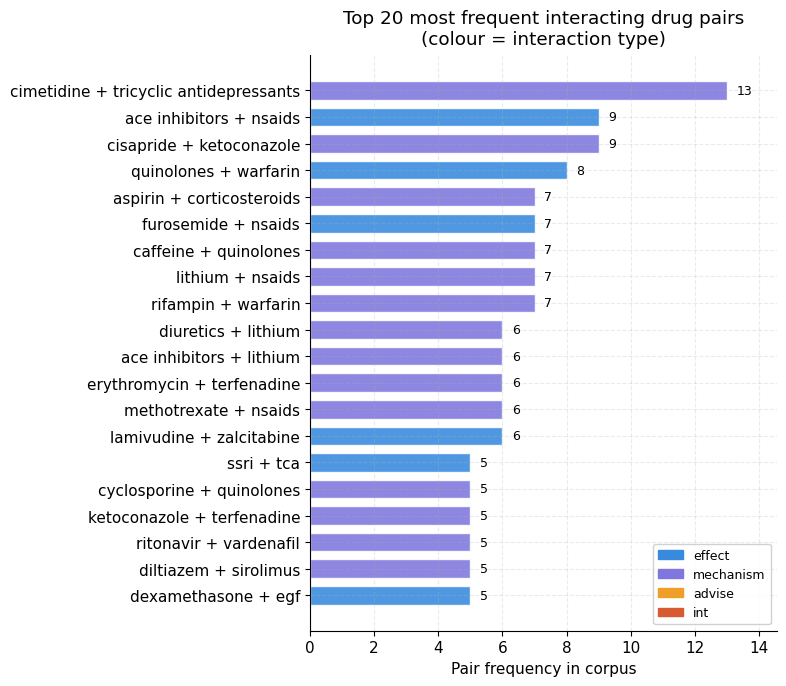

In [20]:
pos_df = df[df['ddi'] == True].copy()

pair_type  = {}
pair_count = Counter()

for _, row in pos_df.iterrows():
    d1 = str(row['drug1_text']).lower().strip()
    d2 = str(row['drug2_text']).lower().strip()
    pair = tuple(sorted([d1, d2]))

    pair_count[pair] += 1

    existing = pair_type.get(pair, 'int')
    priority = {'mechanism': 0, 'effect': 1, 'advise': 2, 'int': 3}

    if priority.get(row['interaction_type'], 3) < priority.get(existing, 3):
        pair_type[pair] = row['interaction_type']


top_pairs = pair_count.most_common(20)


# -------------------------------
# Plot 1 — Top Interacting Pairs
# -------------------------------
plt.figure(figsize=(8, 7))

pair_labels  = [f'{p[0][0]} + {p[0][1]}' for p in top_pairs]
pair_vals    = [p[1] for p in top_pairs]
pair_colours = [LABEL_COLOURS.get(pair_type.get(p[0], 'int'), '#888780') for p in top_pairs]

plt.barh(
    pair_labels[::-1],
    pair_vals[::-1],
    color=pair_colours[::-1],
    edgecolor='white',
    alpha=0.88,
    height=0.7
)

for i, val in enumerate(pair_vals[::-1]):
    plt.text(val + 0.3, i, str(val), va='center', fontsize=9)

plt.title('Top 20 most frequent interacting drug pairs\n(colour = interaction type)', pad=8)
plt.xlabel('Pair frequency in corpus')
plt.margins(x=0.12)

patches = [mpatches.Patch(color=LABEL_COLOURS[l], label=l) for l in LABEL_ORDER[1:]]
plt.legend(handles=patches, fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout()
save_fig('13_top_pairs')

## Interaction Network Graph

This graph represents drug–drug relationships as a network:

- Nodes → drugs  
- Edges → interactions between drugs  
- Edge thickness → frequency of interaction  
- Edge colour → interaction type  

This helps visualise clusters of frequently interacting drugs and identifies central drugs with multiple interactions.

Network graph drawn using networkx.
Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/14_interaction_network.png
Unique interacting pairs : 4,046
Pairs appearing once : 3,396
Most frequent pair : cimetidine + tricyclic antidepressants (13×)

Suggested pairs for Phase 6 demo:
cimetidine + tricyclic antidepressants — mechanism (13×)
ace inhibitors + nsaids — effect (9×)
cisapride + ketoconazole — mechanism (9×)
quinolones + warfarin — effect (8×)
aspirin + corticosteroids — mechanism (7×)


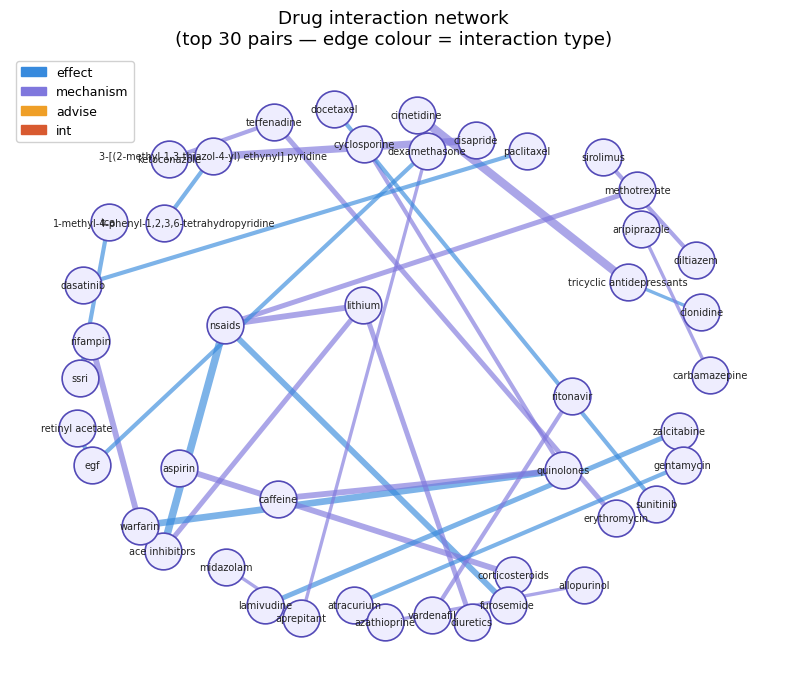

In [21]:
# -------------------------------
# Plot 2 — Interaction Network
# -------------------------------
plt.figure(figsize=(8, 7))

try:
    import networkx as nx

    G = nx.Graph()

    for (d1, d2), count in pair_count.most_common(30):
        G.add_edge(
            d1, d2,
            weight=count,
            label=pair_type.get(tuple(sorted([d1, d2])), 'int')
        )

    pos = nx.spring_layout(G, seed=42, k=2.8)

    ecols = [LABEL_COLOURS.get(G[u][v]['label'], '#888780') for u, v in G.edges()]
    ewidths = [min(G[u][v]['weight'] * 0.6, 6) for u, v in G.edges()]

    nx.draw_networkx_nodes(
        G, pos,
        node_color='#EEEDFE',
        node_size=700,
        edgecolors='#534AB7',
        linewidths=1.2
    )

    nx.draw_networkx_labels(G, pos, font_size=7, font_color='#222')

    nx.draw_networkx_edges(
        G, pos,
        edge_color=ecols,
        width=ewidths,
        alpha=0.65
    )

    patches2 = [mpatches.Patch(color=LABEL_COLOURS[l], label=l) for l in LABEL_ORDER[1:]]
    plt.legend(handles=patches2, fontsize=9, loc='upper left', framealpha=0.9)

    plt.title('Drug interaction network\n(top 30 pairs — edge colour = interaction type)', pad=8)
    plt.axis('off')

    print('Network graph drawn using networkx.')

except ImportError:
    plt.text(
        0.5, 0.5,
        'Install networkx:\npip install networkx',
        ha='center', va='center',
        transform=plt.gca().transAxes,
        fontsize=11
    )
    plt.axis('off')
    print('networkx not installed. Run: pip install networkx')

plt.tight_layout()
save_fig('14_interaction_network')


# -------------------------------
# Summary Statistics
# -------------------------------
print(f'Unique interacting pairs : {len(pair_count):,}')
print(f'Pairs appearing once : {sum(1 for c in pair_count.values() if c==1):,}')
print(f'Most frequent pair : {top_pairs[0][0][0]} + {top_pairs[0][0][1]} ({top_pairs[0][1]}×)')

print('\nSuggested pairs for Phase 6 demo:')
for (d1, d2), cnt in top_pairs[:5]:
    itype = pair_type.get((d1, d2), 'int')
    print(f'{d1} + {d2} — {itype} ({cnt}×)')

## Drug Position Analysis

This section analyses the positional relationship between interacting drug entities within a sentence.

- Computes the **word distance** between `drug1` and `drug2`  
- Evaluates how this distance varies across interaction types  
- Visualises:
  - Distribution of distances using violin plots  
  - Average distance per interaction class  

This helps determine whether proximity between drug mentions is a useful signal for interaction prediction.

In [22]:
def get_drug_distance(row):
    words = str(row['sentence_text']).lower().split()
    d1 = str(row['drug1_text']).lower()
    d2 = str(row['drug2_text']).lower()

    pos1 = next((i for i, w in enumerate(words) if d1 in w), None)
    pos2 = next((i for i, w in enumerate(words) if d2 in w), None)

    return abs(pos1 - pos2) if pos1 is not None and pos2 is not None else None


print('Computing drug distances (may take ~30 seconds)...')
df['drug_distance'] = df.apply(get_drug_distance, axis=1)

Computing drug distances (may take ~30 seconds)...


## Distance Distribution by Interaction Type

This plot shows how the distance between drug mentions varies across different interaction classes.

- Violin plots capture full distribution (not just summary stats)  
- Median distance is annotated for clarity  
- Helps identify whether interacting drugs tend to appear closer in text  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/14_distance_distribution.png


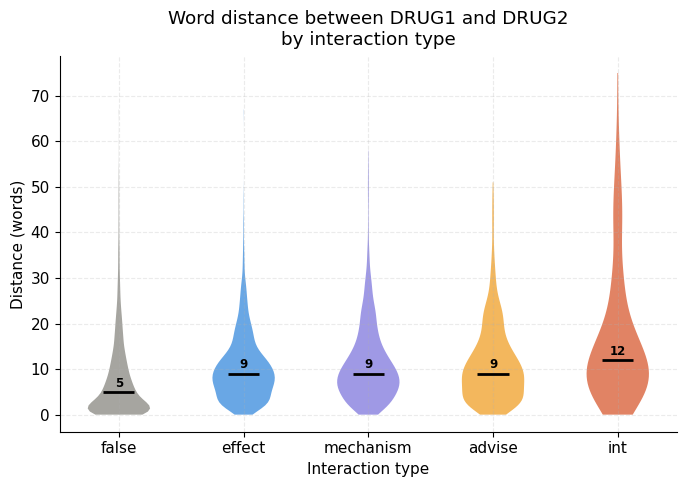

In [23]:
# Plot 1 — Violin Distribution
plt.figure(figsize=(7, 5))

data = [
    df[df['interaction_type'] == l]['drug_distance'].dropna().values
    for l in LABEL_ORDER
]

parts = plt.violinplot(
    data,
    positions=range(len(LABEL_ORDER)),
    showmedians=True,
    showextrema=False
)

for pc, label in zip(parts['bodies'], LABEL_ORDER):
    pc.set_facecolor(LABEL_COLOURS[label])
    pc.set_alpha(0.75)

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

plt.xticks(range(len(LABEL_ORDER)), LABEL_ORDER)
plt.title('Word distance between DRUG1 and DRUG2\nby interaction type', pad=8)
plt.xlabel('Interaction type')
plt.ylabel('Distance (words)')

for i, label in enumerate(LABEL_ORDER):
    median = np.nanmedian(data[i])
    plt.text(i, median + 0.5, f'{median:.0f}',
             ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')

plt.tight_layout()
save_fig('14_distance_distribution')

## Mean Distance Comparison

This plot summarises the **average distance** between drug pairs per interaction class.

- Provides a simpler, aggregated view of the same signal  
- Useful for feature validation in downstream models  

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/eda/15_distance_mean.png
Mean word distance by class:
false        8.0 words
effect       10.3 words
mechanism    11.3 words
advise       11.4 words
int          16.7 words

Distance varies meaningfully between classes => drug_distance feature is justified.


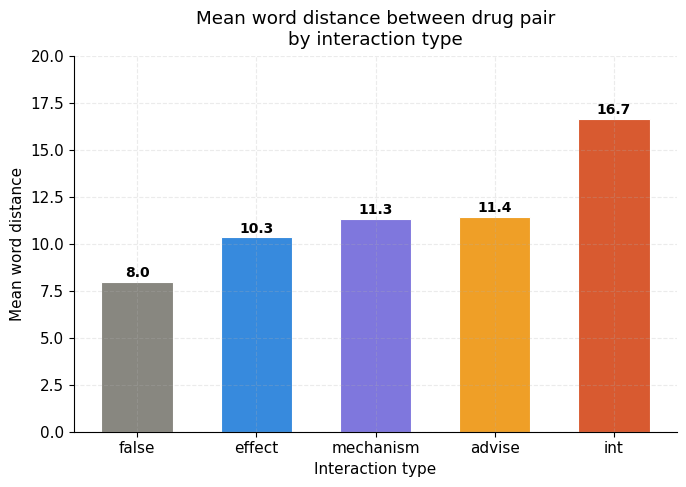

In [24]:
# Plot 2 — Mean Distance
plt.figure(figsize=(7, 5))

means = df.groupby('interaction_type')['drug_distance'].mean().reindex(LABEL_ORDER)

bars = plt.bar(
    LABEL_ORDER,
    means.values,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

for bar, val in zip(bars, means.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val:.1f}',
        ha='center', va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Mean word distance between drug pair\nby interaction type', pad=8)
plt.xlabel('Interaction type')
plt.ylabel('Mean word distance')
plt.ylim(0, means.max() * 1.2)

plt.tight_layout()
save_fig('15_distance_mean')


# Summary
print('Mean word distance by class:')
for label, mean in means.items():
    print(f'{label:<12} {mean:.1f} words')

print()
if means.std() > 1:
    print('Distance varies meaningfully between classes => drug_distance feature is justified.')
else:
    print('Distance shows limited variation — feature may contribute little in Phase 4.')

## EDA Summary Tables for Reporting

This section consolidates key statistics from the exploratory analysis into structured tables for reporting.

### Class-Level Summary
For each interaction type, the following metrics are computed:
- Train, test, and total sample counts  
- Percentage share of the dataset  
- Mean sentence length  
- Negation rate  

This table provides a compact overview of class distribution, imbalance, and linguistic characteristics.

### Source-Level Summary
Aggregates statistics by corpus source (DrugBank vs MedLine):
- Total number of pairs  
- Number of interacting pairs  
- Interaction rate (%)  
- Number of unique source files  
- Average sentence length  

These summaries are saved as CSV files for direct inclusion in the final report and further analysis.

In [25]:
# ── Aggregate statistics for report ──────────────────────────────────────────

counts_train = train_df['interaction_type'].value_counts().reindex(LABEL_ORDER)
counts_test  = test_df['interaction_type'].value_counts().reindex(LABEL_ORDER)
counts_total = df['interaction_type'].value_counts().reindex(LABEL_ORDER)

means_len = df.groupby('interaction_type')['sentence_length'].mean().reindex(LABEL_ORDER)


# -------------------------------
# Class-level summary table
# -------------------------------
summary_rows = []

for label in LABEL_ORDER:
    summary_rows.append({
        'interaction_type': label,
        'train_count': counts_train[label],
        'test_count': counts_test[label],
        'total_count': counts_total[label],
        'total_pct': round(counts_total[label] / len(df) * 100, 2),
        'mean_sentence_len': round(means_len[label], 1),
        'negation_rate_pct': round(neg_rates.get(label, 0), 2),
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = Path(EDA_CLASS_SUMMARY_CSV)
summary_df.to_csv(summary_path, index=False)

print(f'Saved -> {summary_path}\n')
print(summary_df.to_string(index=False))


# -------------------------------
# Source-level summary table
# -------------------------------
source_summary = df.groupby('corpus_source').agg(
    total_pairs     = ('sentence_id', 'count'),
    interactions    = ('ddi', 'sum'),
    unique_files    = ('source_file', 'nunique'),
    mean_sent_len   = ('sentence_length', 'mean'),
).reset_index()

source_summary['interaction_rate_pct'] = (
    source_summary['interactions'] / source_summary['total_pairs'] * 100
).round(1)

source_summary['mean_sent_len'] = source_summary['mean_sent_len'].round(1)

source_path = Path(EDA_SOURCE_SUMMARY_CSV)
source_summary.to_csv(source_path, index=False)

print(f'\nSaved -> {source_path}\n')
print(source_summary.to_string(index=False))

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/metrics/eda/eda_class_summary.csv

interaction_type  train_count  test_count  total_count  total_pct  mean_sentence_len  negation_rate_pct
           false        23771        5678        29449      85.49               36.0              21.27
          effect         1687         360         2047       5.94               25.5               7.38
       mechanism         1319         302         1621       4.71               29.1               8.39
          advise          826         221         1047       3.04               27.0              29.89
             int          189          96          285       0.83               35.9               3.16

Saved -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/metrics/eda/eda_source_summary.csv

corpus_source  total_pairs  interactions  unique_files  mean_sent_len  interaction_rate_pct
     DrugBank   

## Summary

This notebook performs a comprehensive exploratory data analysis (EDA) of the SemEval-2013 DDI dataset to understand its structure, distribution, and key characteristics.

The analysis reveals a strong class imbalance, with the majority of samples belonging to the `false` (no interaction) class, justifying the use of metrics like Macro F1 and class balancing techniques in later stages. Sentence-level analysis shows moderate variation in length across classes, while token-level analysis confirms that a maximum sequence length of 128 is sufficient for transformer-based models with minimal truncation.

Drug-level insights highlight a long-tail distribution, where a few drugs and drug pairs dominate the dataset. Interaction patterns, keyword presence, and negation analysis demonstrate that linguistic signals—such as domain-specific terms and negation words—are meaningful features and should be preserved during preprocessing.

Structural analysis further shows that multiple drug pairs can originate from a single sentence, contributing to class imbalance and data complexity. Additionally, positional features like the distance between drug mentions provide useful signals for interaction prediction.

Overall, the findings from this EDA directly inform design choices in subsequent phases, including feature engineering, model selection, and evaluation strategy.